# Training Pipeline — XAUUSD M5 Signal Model (Walk-Forward)

**Việc bạn cần làm:** Chạy 2 ô đầu để kết nối Google Drive + cài thư viện, chỉnh `data_folder`/`data_file` ở ô **[CONFIG]** cho đúng vị trí file CSV trên Drive của bạn, sau đó **Run All**. Toàn bộ pipeline còn lại (feature engineering → labeling → walk-forward validation → train model cuối → lưu file) chạy tự động.

**Input mong đợi:** file CSV OHLCV XAUUSD khung M5 xuất từ MT5/Exness, đặt trong Google Drive, tối thiểu các cột: `time, open, high, low, close, spread` (tên cột không phân biệt hoa/thường, notebook sẽ tự chuẩn hoá).

**Output:** 2 file model được lưu vào Google Drive tại `<data_folder>/models/clf_model.json` và `<data_folder>/models/reg_model.json` — sau khi train xong, tải 2 file này về và copy vào thư mục `models/` của dự án local (đúng cấu trúc mà `model_engine.py` sẽ load khi `run.py` khởi động).


## 1. Kết nối Google Drive & Cài đặt thư viện (Google Colab)

In [1]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [2]:
# Cài các thư viện cần thiết (Colab đã có sẵn pandas/numpy/sklearn/matplotlib,
# chỉ cần cài thêm xgboost nếu bản có sẵn chưa đủ mới)
!pip install -q xgboost --upgrade

import pandas as pd
import numpy as np
import xgboost as xgb
from sklearn.metrics import accuracy_score, roc_auc_score, mean_absolute_error, classification_report
import matplotlib.pyplot as plt
import json
import os
import warnings
warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", 50)
print("Đã import xong. xgboost version:", xgb.__version__)


Đã import xong. xgboost version: 3.3.0


## 2. [CONFIG] — Chỉnh ở đây, phần còn lại không cần đụng vào

- `data_folder` / `data_file`: đường dẫn thư mục & tên file CSV dữ liệu M5 XAUUSD trên Google Drive của bạn.
- `SEQUENCE_LENGTH`: số nến đầu vào cho 1 mẫu (mặc định 10, theo đặc tả).
- `ATR_DEADZONE_MULTIPLIER`: hệ số xác định vùng "đi ngang" khi gán nhãn (mục 3.3 trong tài liệu đặc tả).
- `MIN_TRAIN_MONTHS`: số tháng tối thiểu dùng để train ở fold đầu tiên của walk-forward.

⚠️ **Lưu ý Colab:** model sau khi train cũng được lưu thẳng vào Google Drive (`MODEL_OUTPUT_DIR`), không lưu vào ổ đĩa tạm của Colab — vì runtime Colab bị xoá sạch sau khi disconnect, lưu local sẽ mất hết kết quả train.


In [ ]:
# ==================== [CONFIG] ====================
data_folder = '/content/drive/MyDrive/forex_data'   # Thay đổi nếu folder của bạn khác
data_file   = 'XAUUSD_m5.csv'                        # Thay đổi nếu tên file của bạn khác

DATA_PATH = os.path.join(data_folder, data_file)

SYMBOL = "XAUUSD"
SEQUENCE_LENGTH = 10                     # số nến đầu vào (mục 1.2 đặc tả)
ATR_PERIOD = 14
ATR_DEADZONE_MULTIPLIER = 0.25           # tăng từ 0.1 -> 0.25: lọc bớt nhiễu micro-noise trên M5,
                                          # giúp 2 lớp Tăng/Giảm "sạch" hơn -> model dễ học pattern thật hơn.
                                          # Thử 0.2 - 0.4 tuỳ % mẫu còn lại sau lọc dead-zone (in ra ở mục 5).
MIN_TRAIN_MONTHS = 3                     # tăng từ 1 -> 3: fold đầu chỉ ~1 tháng dữ liệu quá ít, khiến
                                          # model overfit ngay fold đầu và kéo trung bình cả walk-forward xuống.

# Bật nếu CSV có cột tick_volume/volume (khuyến nghị bật nếu Valentine đã bổ sung cột này)
USE_TICK_VOLUME = True

# Model lưu vào Google Drive để không bị mất khi Colab ngắt kết nối
MODEL_OUTPUT_DIR = os.path.join(data_folder, "models")
CLF_MODEL_PATH = os.path.join(MODEL_OUTPUT_DIR, "clf_model.json")
REG_MODEL_PATH = os.path.join(MODEL_OUTPUT_DIR, "reg_model.json")

os.makedirs(MODEL_OUTPUT_DIR, exist_ok=True)
print(f"Sẽ đọc dữ liệu từ: {DATA_PATH}")
print(f"Model sẽ được lưu vào: {CLF_MODEL_PATH} và {REG_MODEL_PATH}")


## 3. Nạp & chuẩn hoá dữ liệu

Tự động nhận diện tên cột phổ biến khi export từ MT5 (`Time/time/Date`, `Open/open`, ...), chuẩn hoá về chữ thường, parse datetime, sort theo thời gian, và tách cột `month` phục vụ walk-forward split (mục 3.4).


In [ ]:
START_DATE = "2024-01-01"                # Ví dụ: chỉ lấy từ năm 2024
END_DATE   = "2026-07-10"

def load_and_normalize_csv(path: str) -> pd.DataFrame:
    df = pd.read_csv(path)
    df.columns = [c.strip().lower() for c in df.columns]

    # Chuẩn hoá tên cột thời gian phổ biến khi export từ MT5
    time_col_candidates = ["time", "date", "datetime", "timestamp"]
    time_col = next((c for c in time_col_candidates if c in df.columns), None)
    if time_col is None:
        raise ValueError(f"Không tìm thấy cột thời gian. Các cột hiện có: {list(df.columns)}")
    df = df.rename(columns={time_col: "time"})
    df["time"] = pd.to_datetime(df["time"])

    # 🛠️ TỰ ĐỘNG ĐỌC TỪ CONFIG KHÔNG CẦN QUA GỌI HÀM
    if 'START_DATE' in globals() and START_DATE is not None:
      df = df[df["time"] >= pd.to_datetime(START_DATE)]
    if 'END_DATE' in globals() and END_DATE is not None:
      df = df[df["time"] <= pd.to_datetime(END_DATE)]

    required = ["open", "high", "low", "close"]
    missing = [c for c in required if c not in df.columns]
    if missing:
        raise ValueError(f"Thiếu cột bắt buộc: {missing}. Các cột hiện có: {list(df.columns)}")

    if "spread" not in df.columns:
        print("⚠️  Không có cột 'spread' trong file CSV — tạm gán spread=0. "
              "Nên bổ sung để Feature Spread_norm và Spread Anomaly Filter hoạt động chính xác.")
        df["spread"] = 0.0

    # Nhận diện cột volume phổ biến khi export MT5. tick_volume là số lượng tick/báo giá trong nến
    # (không phải volume sàn thật vì gold/forex là thị trường OTC), nhưng vẫn phản ánh mật độ giao dịch
    # và thường có giá trị dự báo tốt hơn là bỏ qua hoàn toàn.
    volume_col_candidates = ["tick_volume", "volume", "real_volume"]
    volume_col = next((c for c in volume_col_candidates if c in df.columns), None)
    if volume_col is not None:
        df = df.rename(columns={volume_col: "tick_volume"})
    else:
        if USE_TICK_VOLUME:
            print("⚠️  USE_TICK_VOLUME=True nhưng không tìm thấy cột volume/tick_volume trong CSV — "
                  "feature volume_z sẽ tự động fallback về 0 (xem mục 4).")
        df["tick_volume"] = np.nan

    df = df.sort_values("time").reset_index(drop=True)
    df["month"] = df["time"].dt.to_period("M").astype(str)
    return df[["time", "open", "high", "low", "close", "spread", "tick_volume", "month"]]


df_raw = load_and_normalize_csv(DATA_PATH)
print(f"Đã nạp {len(df_raw)} nến, từ {df_raw['time'].min()} đến {df_raw['time'].max()}")
print(f"Số tháng có dữ liệu: {df_raw['month'].nunique()} -> {sorted(df_raw['month'].unique())}")
df_raw.head()


## 4. Feature Engineering — 4 chiều/nến + ATR (mục 2.2, 2.3 đặc tả)

`candle_to_vector()` giữ đúng công thức trong tài liệu đặc tả: Thân nến %, Râu trên %, Râu dưới %, Spread chuẩn hoá theo biên độ nến.


In [ ]:
def candle_to_vector_vectorized(df: pd.DataFrame):
    """Vectorized version — không dùng iterrows() (chậm ~50-100x trên vài trăm nghìn dòng)."""
    o, h, l, c, spread = df["open"], df["high"], df["low"], df["close"], df["spread"]
    body = (c - o) / o * 100
    upper = (h - np.maximum(o, c)) / o * 100
    lower = (np.minimum(o, c) - l) / o * 100
    rng = (h - l).clip(lower=1e-9)
    spread_norm = spread / rng
    return body, upper, lower, spread_norm


def add_features(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    close, high, low = df["close"], df["high"], df["low"]

    # --- 1. Hình dạng nến (giữ nguyên công thức đặc tả, chỉ vectorize cho nhanh) ---
    df["body_pct"], df["upper_pct"], df["lower_pct"], df["spread_norm"] = candle_to_vector_vectorized(df)

    # --- 2. ATR(14) — dùng cho SL nội suy, ngưỡng dead-zone, và chuẩn hoá các feature bên dưới ---
    tr = pd.concat([
        high - low,
        (high - close.shift()).abs(),
        (low - close.shift()).abs()
    ], axis=1).max(axis=1)
    df["atr"] = tr.rolling(ATR_PERIOD).mean()
    atr_safe = df["atr"].clip(lower=1e-9)

    # --- 3. Log-return + volatility regime (thân nến % thôi không nói được biến động đang cao hay thấp) ---
    df["log_ret"] = np.log(close / close.shift()).fillna(0)
    df["atr_pct"] = df["atr"] / close * 100

    # --- 4. Trend context: EMA20/EMA50, khoảng cách theo ATR + độ dốc EMA ---
    ema20 = close.ewm(span=20, adjust=False).mean()
    ema50 = close.ewm(span=50, adjust=False).mean()
    df["ema20_dist"] = (close - ema20) / atr_safe
    df["ema50_dist"] = (close - ema50) / atr_safe
    df["ema_slope"] = (ema20 - ema20.shift(5)) / atr_safe

    # --- 5. RSI(14) ---
    delta = close.diff()
    gain = delta.clip(lower=0)
    loss = -delta.clip(upper=0)
    avg_gain = gain.ewm(alpha=1/14, min_periods=14, adjust=False).mean()
    avg_loss = loss.ewm(alpha=1/14, min_periods=14, adjust=False).mean()
    rs = avg_gain / avg_loss.replace(0, 1e-9)
    df["rsi14"] = (100 - 100 / (1 + rs)) / 100   # scale 0-1

    # --- 6. MACD histogram, chuẩn hoá theo ATR để ổn định qua các vùng giá vàng khác nhau ---
    ema12 = close.ewm(span=12, adjust=False).mean()
    ema26 = close.ewm(span=26, adjust=False).mean()
    macd = ema12 - ema26
    macd_signal = macd.ewm(span=9, adjust=False).mean()
    df["macd_hist"] = (macd - macd_signal) / atr_safe

    # --- 7. ADX(14) — sức mạnh xu hướng (giúp model phân biệt trending vs sideways) ---
    up_move = high.diff()
    down_move = -low.diff()
    plus_dm = np.where((up_move > down_move) & (up_move > 0), up_move, 0.0)
    minus_dm = np.where((down_move > up_move) & (down_move > 0), down_move, 0.0)
    tr_smooth = tr.ewm(alpha=1/14, min_periods=14, adjust=False).mean().clip(lower=1e-9)
    plus_di = 100 * pd.Series(plus_dm, index=df.index).ewm(alpha=1/14, min_periods=14, adjust=False).mean() / tr_smooth
    minus_di = 100 * pd.Series(minus_dm, index=df.index).ewm(alpha=1/14, min_periods=14, adjust=False).mean() / tr_smooth
    dx = 100 * (plus_di - minus_di).abs() / (plus_di + minus_di).replace(0, 1e-9)
    df["adx14"] = dx.ewm(alpha=1/14, min_periods=14, adjust=False).mean() / 100

    # --- 8. Bollinger Band width — đo trạng thái squeeze/breakout ---
    sma20 = close.rolling(20).mean()
    std20 = close.rolling(20).std()
    df["bb_width"] = (4 * std20) / sma20.clip(lower=1e-9) * 100

    # --- 9. Volume z-score (chỉ có nếu CSV có tick_volume, xem mục 3) ---
    if "tick_volume" in df.columns and df["tick_volume"].notna().any():
        vol_mean = df["tick_volume"].rolling(50).mean()
        vol_std = df["tick_volume"].rolling(50).std().replace(0, 1e-9)
        df["volume_z"] = (df["tick_volume"] - vol_mean) / vol_std
    else:
        df["volume_z"] = 0.0

    # --- 10. Thời gian trong ngày / phiên giao dịch (theo giờ trong cột time của CSV) ---
    hour_frac = df["time"].dt.hour + df["time"].dt.minute / 60
    df["hour_sin"] = np.sin(2 * np.pi * hour_frac / 24)
    df["hour_cos"] = np.cos(2 * np.pi * hour_frac / 24)
    dow = df["time"].dt.dayofweek
    df["dow_sin"] = np.sin(2 * np.pi * dow / 7)
    df["dow_cos"] = np.cos(2 * np.pi * dow / 7)
    # ⚠️ Khoảng giờ overlap London/NY dưới đây giả định "time" là giờ server broker (Exness mặc định ~GMT+2/+3).
    # Nếu broker của bạn dùng offset khác, chỉnh lại khoảng giờ cho khớp phiên NY/London thật.
    df["session_overlap"] = df["time"].dt.hour.between(14, 17).astype(float)

    return df


df_feat = add_features(df_raw)
df_feat = df_feat.dropna().reset_index(drop=True)   # loại vài chục dòng đầu chưa đủ EMA50/rolling(50) để tính

FEATURE_COLS = ["body_pct", "upper_pct", "lower_pct", "spread_norm", "log_ret", "atr_pct",
                 "ema20_dist", "ema50_dist", "ema_slope", "rsi14", "macd_hist", "adx14",
                 "bb_width", "volume_z", "hour_sin", "hour_cos", "dow_sin", "dow_cos", "session_overlap"]

print(f"Còn lại {len(df_feat)} nến sau khi tính feature + loại bỏ NaN đầu chuỗi.")
print(f"Số feature/nến: {len(FEATURE_COLS)} (bản cũ: 4) -> input model: {SEQUENCE_LENGTH} x {len(FEATURE_COLS)} = {SEQUENCE_LENGTH*len(FEATURE_COLS)} chiều")
df_feat[["time"] + FEATURE_COLS].head()


## 5. Gán nhãn (Dead-zone Labeling, mục 3.3) & Tạo chuỗi 10 nến → dự đoán nến 11

`label_candle_11()` giữ đúng logic 3 lớp (Tăng rõ ràng / Giảm rõ ràng / Đi ngang) từ tài liệu đặc tả, dùng `ATR_DEADZONE_MULTIPLIER` làm ngưỡng.

⚠️ **Không có look-ahead bias**: nhãn của mẫu tại vị trí `i` (chuỗi nến `i-10..i-1`) chỉ dùng thông tin của nến `i` (Open, Close) để tính nhãn — không dùng bất kỳ thông tin nào sau nến `i`.


In [ ]:
def label_candle_11(open_11, close_11, atr_threshold):
    pct_change = (close_11 - open_11) / open_11 * 100
    if pct_change > atr_threshold:
        direction_label = 1
    elif pct_change < -atr_threshold:
        direction_label = -1
    else:
        direction_label = 0          # dead-zone
    magnitude_label = abs(pct_change)
    return direction_label, magnitude_label


def build_sequences(df: pd.DataFrame, seq_len: int = SEQUENCE_LENGTH):
    """
    Trả về:
      X          : ma trận (n_samples, seq_len * len(FEATURE_COLS))
      direction  : nhãn hướng (-1 / 0 / 1)
      magnitude  : nhãn biên độ (%)
      months     : tháng của nến mục tiêu (dùng cho walk-forward split)
    """
    feats = df[FEATURE_COLS].values
    atr = df["atr"].values
    opens = df["open"].values
    closes = df["close"].values
    months = df["month"].values

    n = len(df)
    n_samples = n - seq_len
    n_feat = len(FEATURE_COLS)
    X = np.empty((n_samples, seq_len * n_feat), dtype=np.float64)
    direction = np.empty(n_samples, dtype=np.int64)
    magnitude = np.empty(n_samples, dtype=np.float64)
    months_out = np.empty(n_samples, dtype=months.dtype)

    for k, i in enumerate(range(seq_len, n)):
        X[k] = feats[i - seq_len:i].flatten()
        atr_threshold = ATR_DEADZONE_MULTIPLIER * atr[i - 1]
        d_label, m_label = label_candle_11(opens[i], closes[i], atr_threshold)
        direction[k] = d_label
        magnitude[k] = m_label
        months_out[k] = months[i]

    return X, direction, magnitude, months_out


X_all, y_direction_all, y_magnitude_all, months_all = build_sequences(df_feat)
n_total = len(y_direction_all)
n_up = int(np.sum(y_direction_all == 1)); n_down = int(np.sum(y_direction_all == -1)); n_flat = int(np.sum(y_direction_all == 0))
print(f"Tổng số mẫu: {n_total} | Số chiều feature: {X_all.shape[1]} (kỳ vọng {SEQUENCE_LENGTH*len(FEATURE_COLS)})")
print(f"Phân phối nhãn hướng: Tăng={n_up} ({n_up/n_total*100:.1f}%), "
      f"Giảm={n_down} ({n_down/n_total*100:.1f}%), "
      f"Đi ngang(dead-zone)={n_flat} ({n_flat/n_total*100:.1f}%)")
if n_flat / n_total > 0.6:
    print("⚠️  Dead-zone > 60% tổng số mẫu -> ATR_DEADZONE_MULTIPLIER có thể đang quá cao, cân nhắc giảm bớt.")
elif n_flat / n_total < 0.15:
    print("⚠️  Dead-zone < 15% tổng số mẫu -> nhãn có thể vẫn còn nhiều nhiễu, cân nhắc tăng ATR_DEADZONE_MULTIPLIER.")


## 6. Walk-Forward Validation (mục 3.4 đặc tả)

Train tăng dần theo tháng, test trên tháng kế tiếp — lặp lại qua toàn bộ dữ liệu để đánh giá tính ổn định của model qua nhiều giai đoạn thị trường, thay vì chỉ 1 lần train/test như thiết kế v1.


In [ ]:
unique_months = sorted(pd.Series(months_all).unique())
print(f"Có {len(unique_months)} tháng dữ liệu: {unique_months}")

if len(unique_months) <= MIN_TRAIN_MONTHS:
    print("⚠️  CẢNH BÁO: chưa đủ tháng dữ liệu để chạy walk-forward validation có ý nghĩa "
          "(khuyến nghị tối thiểu 6 tháng, xem mục 3.4 đặc tả). Sẽ vẫn chạy nhưng kết quả chỉ mang tính tham khảo.")


def get_fold_data(train_months, test_month):
    train_mask = np.isin(months_all, train_months)
    test_mask = months_all == test_month
    return (X_all[train_mask], y_direction_all[train_mask], y_magnitude_all[train_mask],
            X_all[test_mask], y_direction_all[test_mask], y_magnitude_all[test_mask])


def _time_split(X, y, val_ratio=0.15, purge=SEQUENCE_LENGTH):
    """Tách 1 phần cuối (theo thời gian) của tập train làm validation nội bộ cho early stopping.
    `purge` mẫu bị bỏ giữa 2 phần để tránh chồng lấn cửa sổ trượt gây rò rỉ nhẹ giữa train/val."""
    n = len(X)
    if n < 50:
        return X, y, None, None
    cut = max(int(n * (1 - val_ratio)) - purge, 1)
    val_start = min(cut + purge, n - 1)
    if val_start >= n:
        return X, y, None, None
    return X[:cut], y[:cut], X[val_start:], y[val_start:]


def train_fold(X_train, y_dir_train, y_mag_train):
    # Loại dead-zone (label=0) khỏi tập train của model phân loại
    clf_mask = y_dir_train != 0
    X_clf = X_train[clf_mask]
    y_clf = (y_dir_train[clf_mask] == 1).astype(int)   # 0=Giảm, 1=Tăng

    Xc_tr, yc_tr, Xc_val, yc_val = _time_split(X_clf, y_clf)
    Xr_tr, yr_tr, Xr_val, yr_val = _time_split(X_train, y_mag_train)

    clf_params = dict(
        objective="binary:logistic",
        max_depth=4,              # giảm từ 6 -> 4: input 150-190 chiều + cây sâu = dễ overfit lên nhiễu M5
        n_estimators=600,
        learning_rate=0.03,
        subsample=0.8,
        colsample_bytree=0.7,
        min_child_weight=10,
        reg_alpha=0.5,
        reg_lambda=2.0,
        eval_metric="auc",
        n_jobs=-1,
    )
    if Xc_val is not None and len(Xc_val) > 20 and len(np.unique(yc_val)) > 1:
        clf_model = xgb.XGBClassifier(**clf_params, early_stopping_rounds=50)
        clf_model.fit(Xc_tr, yc_tr, eval_set=[(Xc_val, yc_val)], verbose=False)
    else:
        clf_model = xgb.XGBClassifier(**clf_params)
        clf_model.fit(X_clf, y_clf)

    reg_params = dict(
        objective="reg:squarederror",
        max_depth=4,
        n_estimators=600,
        learning_rate=0.03,
        subsample=0.8,
        colsample_bytree=0.7,
        min_child_weight=10,
        reg_alpha=0.5,
        reg_lambda=2.0,
        eval_metric="rmse",
        n_jobs=-1,
    )
    if Xr_val is not None and len(Xr_val) > 20:
        reg_model = xgb.XGBRegressor(**reg_params, early_stopping_rounds=50)
        reg_model.fit(Xr_tr, yr_tr, eval_set=[(Xr_val, yr_val)], verbose=False)
    else:
        reg_model = xgb.XGBRegressor(**reg_params)
        reg_model.fit(X_train, y_mag_train)

    return clf_model, reg_model


def evaluate_fold(clf_model, reg_model, X_test, y_dir_test, y_mag_test):
    result = {}

    clf_mask = y_dir_test != 0
    if clf_mask.sum() > 0:
        X_clf_test = X_test[clf_mask]
        y_clf_test = (y_dir_test[clf_mask] == 1).astype(int)
        y_pred = clf_model.predict(X_clf_test)
        y_proba = clf_model.predict_proba(X_clf_test)[:, 1]
        result["clf_accuracy"] = accuracy_score(y_clf_test, y_pred)
        result["clf_auc"] = roc_auc_score(y_clf_test, y_proba) if len(np.unique(y_clf_test)) > 1 else np.nan
        result["clf_n_samples"] = len(y_clf_test)
    else:
        result["clf_accuracy"] = np.nan
        result["clf_auc"] = np.nan
        result["clf_n_samples"] = 0

    y_mag_pred = reg_model.predict(X_test)
    result["reg_mae"] = mean_absolute_error(y_mag_test, y_mag_pred)
    result["reg_n_samples"] = len(y_mag_test)

    return result


fold_results = []
for i in range(MIN_TRAIN_MONTHS, len(unique_months)):
    train_months = unique_months[:i]
    test_month = unique_months[i]

    X_tr, y_dir_tr, y_mag_tr, X_te, y_dir_te, y_mag_te = get_fold_data(train_months, test_month)
    if len(X_tr) == 0 or len(X_te) == 0:
        continue

    clf_model, reg_model = train_fold(X_tr, y_dir_tr, y_mag_tr)
    metrics = evaluate_fold(clf_model, reg_model, X_te, y_dir_te, y_mag_te)
    metrics["train_months"] = f"{train_months[0]}..{train_months[-1]}"
    metrics["test_month"] = test_month
    fold_results.append(metrics)

    print(f"[Fold test={test_month}] Accuracy={metrics['clf_accuracy']:.3f} | "
          f"AUC={metrics['clf_auc']:.3f} | Magnitude MAE={metrics['reg_mae']:.4f}% "
          f"(n_clf={metrics['clf_n_samples']}, n_reg={metrics['reg_n_samples']})")

fold_df = pd.DataFrame(fold_results)
fold_df


## 7. Biểu đồ độ ổn định qua các fold

Nếu accuracy/AUC dao động mạnh giữa các fold → model chưa đủ ổn định để cân nhắc live (xem cảnh báo ở mục 3.4 và mục 6 của tài liệu đặc tả).


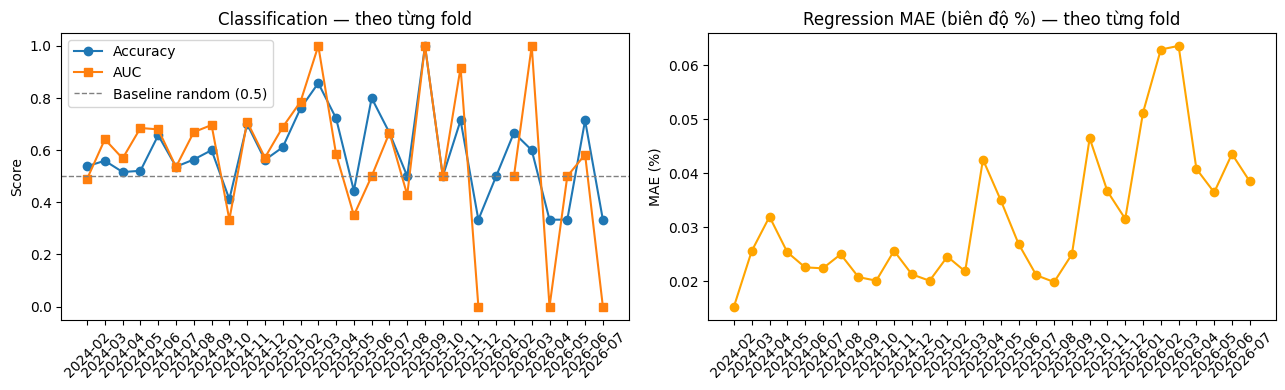


=== Tóm tắt trung bình qua các fold ===
Accuracy trung bình : 0.585 (độ lệch chuẩn 0.161)
AUC trung bình       : 0.572 (độ lệch chuẩn 0.264)
Magnitude MAE TB     : 0.0315% (độ lệch chuẩn 0.0126)


In [22]:
if len(fold_df) > 0:
    fig, axes = plt.subplots(1, 2, figsize=(13, 4))

    axes[0].plot(fold_df["test_month"], fold_df["clf_accuracy"], marker="o", label="Accuracy")
    axes[0].plot(fold_df["test_month"], fold_df["clf_auc"], marker="s", label="AUC")
    axes[0].axhline(0.5, color="gray", linestyle="--", linewidth=1, label="Baseline random (0.5)")
    axes[0].set_title("Classification — theo từng fold")
    axes[0].set_ylabel("Score")
    axes[0].legend()
    axes[0].tick_params(axis="x", rotation=45)

    axes[1].plot(fold_df["test_month"], fold_df["reg_mae"], marker="o", color="orange")
    axes[1].set_title("Regression MAE (biên độ %) — theo từng fold")
    axes[1].set_ylabel("MAE (%)")
    axes[1].tick_params(axis="x", rotation=45)

    plt.tight_layout()
    plt.show()

    print("\n=== Tóm tắt trung bình qua các fold ===")
    print(f"Accuracy trung bình : {fold_df['clf_accuracy'].mean():.3f} (độ lệch chuẩn {fold_df['clf_accuracy'].std():.3f})")
    print(f"AUC trung bình       : {fold_df['clf_auc'].mean():.3f} (độ lệch chuẩn {fold_df['clf_auc'].std():.3f})")
    print(f"Magnitude MAE TB     : {fold_df['reg_mae'].mean():.4f}% (độ lệch chuẩn {fold_df['reg_mae'].std():.4f})")
else:
    print("Chưa có đủ dữ liệu để chạy walk-forward (cần tối thiểu 2 tháng dữ liệu).")


## 8. Train model cuối cùng trên TOÀN BỘ dữ liệu & Lưu file vào Google Drive

Sau khi đã xem kết quả walk-forward ở trên và thấy chấp nhận được, chạy ô dưới để train lại model trên **toàn bộ** dữ liệu hiện có (không chỉ 1 fold) và lưu ra file vào Google Drive — đây là model thực sự sẽ được `run.py` load lên khi chạy real-time. Sau khi train xong, tải 2 file `.json` này về máy và copy vào thư mục `models/` của dự án local.


In [23]:
final_clf_model, final_reg_model = train_fold(X_all, y_direction_all, y_magnitude_all)

final_clf_model.save_model(CLF_MODEL_PATH)
final_reg_model.save_model(REG_MODEL_PATH)

print(f"✅ Đã lưu model phân loại hướng đi -> {CLF_MODEL_PATH}")
print(f"✅ Đã lưu model hồi quy biên độ   -> {REG_MODEL_PATH}")

# Ghi lại thông tin train để đối chiếu sau này (ngày train, số mẫu, khoảng thời gian dữ liệu)
metadata = {
    "symbol": SYMBOL,
    "trained_at": pd.Timestamp.now().isoformat(),
    "data_range": [str(df_raw["time"].min()), str(df_raw["time"].max())],
    "n_samples_total": int(len(X_all)),
    "sequence_length": SEQUENCE_LENGTH,
    "atr_deadzone_multiplier": ATR_DEADZONE_MULTIPLIER,
    "walk_forward_avg_accuracy": float(fold_df["clf_accuracy"].mean()) if len(fold_df) else None,
    "walk_forward_avg_auc": float(fold_df["clf_auc"].mean()) if len(fold_df) else None,
    "walk_forward_avg_mae": float(fold_df["reg_mae"].mean()) if len(fold_df) else None,
}
with open(os.path.join(MODEL_OUTPUT_DIR, "training_metadata.json"), "w", encoding="utf-8") as f:
    json.dump(metadata, f, ensure_ascii=False, indent=2)

print(f"\n✅ Đã lưu metadata train -> {os.path.join(MODEL_OUTPUT_DIR, 'training_metadata.json')}")
print(json.dumps(metadata, ensure_ascii=False, indent=2))


✅ Đã lưu model phân loại hướng đi -> /content/drive/MyDrive/forex_data/models/clf_model.json
✅ Đã lưu model hồi quy biên độ   -> /content/drive/MyDrive/forex_data/models/reg_model.json

✅ Đã lưu metadata train -> /content/drive/MyDrive/forex_data/models/training_metadata.json
{
  "symbol": "XAUUSD",
  "trained_at": "2026-07-10T10:12:10.513577",
  "data_range": [
    "2024-01-01 22:05:00",
    "2026-07-09 13:15:00"
  ],
  "n_samples_total": 179268,
  "sequence_length": 10,
  "atr_deadzone_multiplier": 0.1,
  "walk_forward_avg_accuracy": 0.5852333387030467,
  "walk_forward_avg_auc": 0.5718357659195776,
  "walk_forward_avg_mae": 0.03148477576059887
}


## 9. Feature Importance (tham khảo)

Xem nhóm feature nào (thân nến, râu trên, râu dưới, spread — theo từng nến trong chuỗi 10) đóng góp nhiều nhất vào quyết định của model phân loại.


In [ ]:
feature_names = []
for t in range(SEQUENCE_LENGTH):
    for fname in FEATURE_COLS:
        feature_names.append(f"t-{SEQUENCE_LENGTH-t}_{fname}")

importance = final_clf_model.feature_importances_
top_idx = np.argsort(importance)[::-1][:15]

plt.figure(figsize=(9, 5))
plt.barh([feature_names[i] for i in top_idx][::-1], importance[top_idx][::-1])
plt.title("Top 15 Feature Importance — Model phân loại hướng đi")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()


## 10. Checklist sau khi train xong

- [ ] Đã xem bảng/biểu đồ walk-forward ở mục 6-7, accuracy trung bình có ổn định qua các fold không (không dao động quá mạnh).
- [ ] 2 file `clf_model.json` và `reg_model.json` đã xuất hiện trong `<data_folder>/models/` trên Google Drive.
- [ ] File `training_metadata.json` đã được ghi lại để đối chiếu các lần train sau.
- [ ] Đã tải 2 file model về máy local và copy vào đúng thư mục `models/` của dự án (cùng cấp với `run.py`).
- [ ] Đã cân nhắc: nếu accuracy trung bình gần 0.5 (ngang bằng random), **chưa nên đưa vào chạy live** — xem lại phần 6 "Lộ trình triển khai" trong tài liệu đặc tả trước khi qua bước forward test demo.
